### 1. Download the thermo_kinetics_scripts repository and set the THERMO_DATA_PATH variable
Unfortunately, the exact locations of these files might change as the repo gets updated

Here, we're looking for a beef-ensembles folder full of files like XCHOO_bee.txt

In [109]:
import os
import pickle
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import rmgpy.data.thermo
%matplotlib inline

In [110]:
THERMO_DATA_PATH = os.path.join(os.environ['HOME'], 'thermo_kinetics_scripts/beef-uq/thermo/beef-ensembles')

### 2. Load the copy of surfaceThermoPt111.py in this repository to get the molecule structures

In [111]:
# load their thermo library
thermo_lib_file = os.path.join(os.environ['HOME'], 'thermo_kinetics_scripts/beef-uq/thermo/surfaceThermoPt111.py')

# RMG expects the library in its own directory
lib_dir = os.path.join(os.path.dirname(thermo_lib_file), 'lib')
os.makedirs(lib_dir, exist_ok=True)
shutil.copyfile(thermo_lib_file, os.path.join(lib_dir, os.path.basename(thermo_lib_file)))

thermo_database = rmgpy.data.thermo.ThermoDatabase()
thermo_database.load_libraries(lib_dir)

# Make a list of each molecule and each label
items = [thermo_database.libraries['surfaceThermoPt111'].entries[e].item for e in thermo_database.libraries['surfaceThermoPt111'].entries]
labels = [thermo_database.libraries['surfaceThermoPt111'].entries[e].label for e in thermo_database.libraries['surfaceThermoPt111'].entries]

### 3. Load all the data from the BEE files

In [112]:
def get_name_from_path(path):
    search_pattern = r'beef-ensembles/(.+)_bee.txt'
    m1 = re.search(search_pattern, path)
    if m1 is not None:
        return m1[1]
bee_files = sorted(glob.glob(os.path.join(THERMO_DATA_PATH, '*_bee.txt')))

### 4. Function to match BEEF data to names in library

In [113]:
def get_molecule_by_name(sp_name):
    # Get the molecule that matches the name in the BEEF thermo library
    try:
        entry_index = labels.index(sp_name)
        return items[entry_index]
    except ValueError:
        print(f'Could not find {i} {sp_name} in thermo library')
        return None

### 5. Load BEEF thermo ensemble data and corresponding molecule structure

In [114]:
Hf_ensemble_data = []
molecules = []
for i in range(len(bee_files)):
    species_name = get_name_from_path(bee_files[i])
    molecule = get_molecule_by_name(species_name)
    if molecule is None:
        continue
    molecules.append(molecule)

    species_ensemble_data = []
    # the loaded dataframe has 2 columns: Hf and Delta Hf
    df = pd.read_csv(bee_files[i], sep='\t')
    Hf_ensemble_data.append(df['Hf'].values)

Hf_ensemble_data = np.array(Hf_ensemble_data)

assert Hf_ensemble_data.shape[1] == 2000, 'BEEF ensemble size should be 2000'

N_species = Hf_ensemble_data.shape[0]
print(f'{N_species} species loaded')

cov_Hf = np.cov(Hf_ensemble_data)
assert cov_Hf.shape[0] == N_species
assert len(molecules) == N_species

Could not find 18 CH3OXCO in thermo library
182 species loaded


### 6. Check that the results make sense

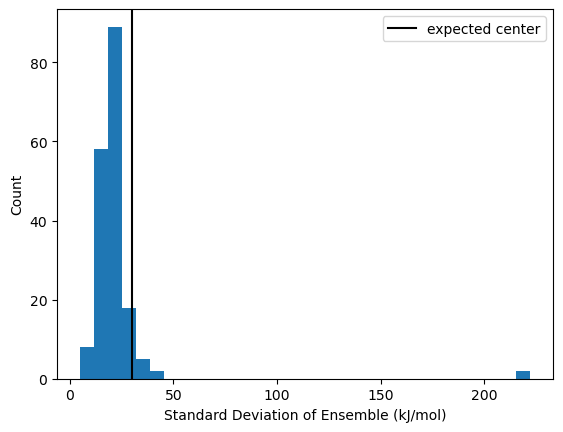

In [115]:
# as of 2026, the BEEF errors should be about 30 kJ/mol, but this may change over time!
assert np.sum(np.diagonal(cov_Hf) == 0) == 0, 'There should not be any zeros in the diagonal of the covariance matrix'
assert np.sum(np.isnan(cov_Hf)) == 0, 'There should not be any nans in the covariance matrix'

diagonal = np.diagonal(cov_Hf)
plt.figure()
plt.hist(np.sqrt(diagonal), bins=32)
plt.axvline(x=30, color='black', label='expected center')
plt.ylabel('Count')
plt.xlabel('Standard Deviation of Ensemble (kJ/mol)')
plt.legend()

# check that the mean uncertainty is +/- 10 kJ/mol of the expected 30 kJ/mol
assert np.isclose(np.mean(np.sqrt(diagonal)), 30, atol=10.0)


Text(0.5, 1.0, 'Thermo Covariance Matrix')

<Figure size 640x480 with 0 Axes>

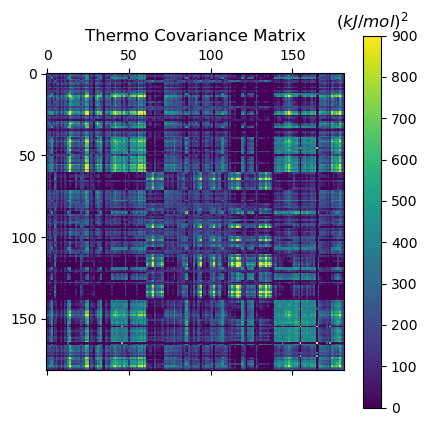

In [116]:
plt.figure()
# Look at the covariance matrix
plt.matshow(cov_Hf)
cb = plt.colorbar()
plt.clim([0, 30 ** 2])
cb.ax.set_title(r'$(kJ/mol)^2$')
plt.title('Thermo Covariance Matrix')

### 7. Save files

In [117]:
thermo_uncertainty_dir = os.path.join(rmgpy.settings['database.directory'], 'thermo', 'uncertainty')
os.makedirs(thermo_uncertainty_dir, exist_ok=True)

cov_mat_file = os.path.join(thermo_uncertainty_dir, os.path.basename(thermo_lib_file).replace('.py', '_cov.npy'))
np.save(cov_mat_file, cov_Hf)

molecule_adjacency_lists = [item.to_adjacency_list() for item in molecules]
molecule_file = os.path.join(thermo_uncertainty_dir, os.path.basename(thermo_lib_file).replace('.py', '_molecules.pickle'))
with open(molecule_file, 'wb') as f:
    pickle.dump(molecule_adjacency_lists, f)